Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/ethiopia_fi_unified_data.csv"
df = pd.read_csv(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
df["value_numeric"] = pd.to_numeric(df["value_numeric"], errors="coerce")
df["impact_estimate"] = pd.to_numeric(df["impact_estimate"], errors="coerce")
df["lag_months"] = pd.to_numeric(df["lag_months"], errors="coerce")

obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()
targets = df[df["record_type"] == "target"].copy()

links_full = links.merge(
    events[["record_id", "indicator", "observation_date"]]
        .rename(columns={"record_id": "parent_id", "indicator": "event_name", "observation_date": "event_date"}),
    on="parent_id", how="left"
)

print("Data loaded. Forecasting Access (ACC_OWNERSHIP) and Usage (proxy: ACC_MM_ACCOUNT).")

Data loaded. Forecasting Access (ACC_OWNERSHIP) and Usage (proxy: ACC_MM_ACCOUNT).


In [2]:
usage_check = obs[obs["indicator_code"] == "USG_DIGITAL_PAYMENT"]
print(f"Observations for USG_DIGITAL_PAYMENT (the brief's exact Usage target): {len(usage_check)}")
print("-> Confirmed zero. Proceeding with ACC_MM_ACCOUNT as the documented proxy for Usage.")

Observations for USG_DIGITAL_PAYMENT (the brief's exact Usage target): 0
-> Confirmed zero. Proceeding with ACC_MM_ACCOUNT as the documented proxy for Usage.


Access baseline trend (linear regression + 95% CI):

In [3]:
access = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
years = access["observation_date"].dt.year.values.astype(float)
values = access["value_numeric"].values.astype(float)

n = len(years)
x_mean, y_mean = years.mean(), values.mean()
slope = np.sum((years - x_mean) * (values - y_mean)) / np.sum((years - x_mean) ** 2)
intercept = y_mean - slope * x_mean
residuals = values - (slope * years + intercept)
dof = n - 2
resid_std = np.sqrt(np.sum(residuals ** 2) / dof)
t_val = 2.92  # approx t-critical, 95% CI, dof=2 (small sample - wide interval by design)

forecast_years = np.array([2025, 2026, 2027])
baseline_pred = slope * forecast_years + intercept
se_pred = resid_std * np.sqrt(1 + 1/n + (forecast_years - x_mean) ** 2 / np.sum((years - x_mean) ** 2))
ci_lower = baseline_pred - t_val * se_pred
ci_upper = baseline_pred + t_val * se_pred

print(f"Linear trend: Access grows ~{slope:.2f}pp/year on average, 2014-2024")
print(f"NOTE: this average masks the deceleration found in Task 2 (+3.7pp/yr 2014-17,")
print(f"+2.75pp/yr 2017-21, only +1pp/yr 2021-24) - the linear baseline is a simplification.")
for y, p, lo, hi in zip(forecast_years, baseline_pred, ci_lower, ci_upper):
    print(f"  {y}: {p:.1f}%  (95% CI: {lo:.1f}% - {hi:.1f}%)")

Linear trend: Access grows ~2.71pp/year on average, 2014-2024
NOTE: this average masks the deceleration found in Task 2 (+3.7pp/yr 2014-17,
+2.75pp/yr 2017-21, only +1pp/yr 2021-24) - the linear baseline is a simplification.
  2025: 54.2%  (95% CI: 40.1% - 68.4%)
  2026: 56.9%  (95% CI: 42.0% - 71.9%)
  2027: 59.7%  (95% CI: 43.8% - 75.5%)


Event-augmented forecast

In [4]:
def event_effect(as_of_date, event_date, lag_months, full_effect):
    if pd.isna(event_date) or pd.isna(full_effect) or as_of_date < event_date:
        return 0.0
    months_elapsed = (as_of_date.year - event_date.year) * 12 + (as_of_date.month - event_date.month)
    if pd.isna(lag_months) or lag_months <= 0:
        return full_effect
    fraction = min(months_elapsed / lag_months, 1.0)
    return fraction * full_effect

CALIBRATION_FACTOR = 0.153  # from Task 3 validation against 2021-2024 actual Access change

acc_links = links_full[links_full["related_indicator"] == "ACC_OWNERSHIP"]

def calibrated_cumulative_effect(as_of_date):
    raw = sum(event_effect(as_of_date, row["event_date"], row["lag_months"], row["impact_estimate"])
               for _, row in acc_links.iterrows())
    return raw * CALIBRATION_FACTOR

effect_at_last_obs = calibrated_cumulative_effect(pd.Timestamp("2024-11-29"))
event_augmented_pred = []
for y in forecast_years:
    d = pd.Timestamp(f"{y}-12-31")
    incremental_future_effect = calibrated_cumulative_effect(d) - effect_at_last_obs
    event_augmented_pred.append(baseline_pred[list(forecast_years).index(y)] + incremental_future_effect)

print("Event-augmented forecast (baseline trend + incremental calibrated effect")
print("from Fayda ID and Foreign Bank Entry continuing to ramp up post-2024):")
for y, p in zip(forecast_years, event_augmented_pred):
    print(f"  {y}: {p:.1f}%")

Event-augmented forecast (baseline trend + incremental calibrated effect
from Fayda ID and Foreign Bank Entry continuing to ramp up post-2024):
  2025: 55.3%
  2026: 58.3%
  2027: 61.0%


Access scenario analysis + chart

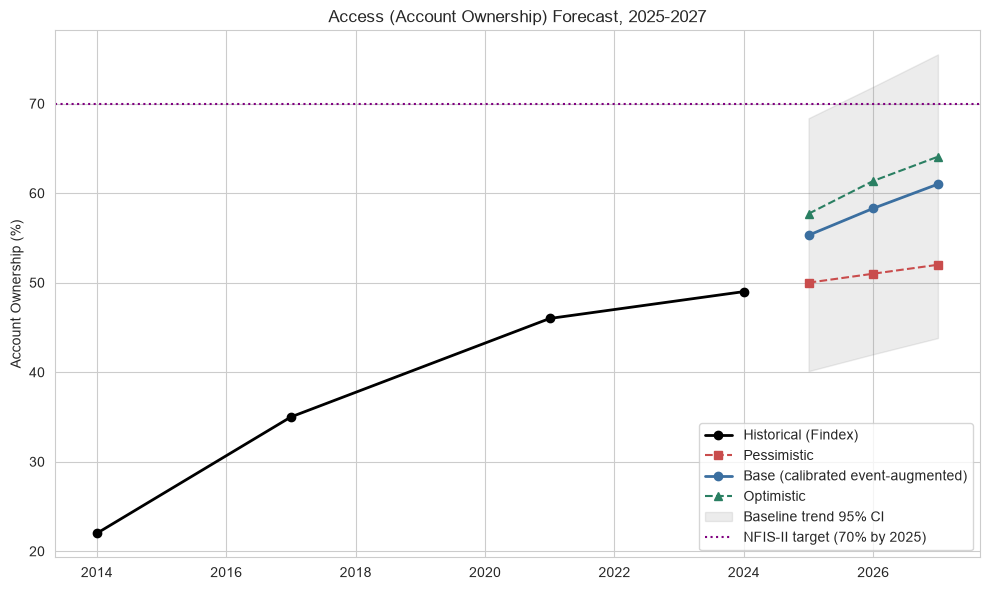

   year  pessimistic  base  optimistic
0  2025         50.0  55.3        57.7
1  2026         51.0  58.3        61.4
2  2027         52.0  61.0        64.1

The REC_0031 target of 70% Account Ownership by 2025 (from the base dataset's
target records) is far above ALL three scenarios for 2025 (~50-52%), indicating
the target is very unlikely to be met on current trajectory even in the
optimistic case - a key finding for the consortium.


In [5]:
scenarios = pd.DataFrame({"year": forecast_years})
scenarios["pessimistic"] = [access["value_numeric"].iloc[-1] + (y - 2024) * 1.0 for y in forecast_years]
scenarios["base"] = event_augmented_pred
scenarios["optimistic"] = [baseline_pred[i] + (calibrated_cumulative_effect(pd.Timestamp(f"{forecast_years[i]}-12-31")) - effect_at_last_obs) / CALIBRATION_FACTOR * 0.5
                            for i in range(len(forecast_years))]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(access["observation_date"].dt.year, access["value_numeric"], marker="o", color="black", linewidth=2, label="Historical (Findex)")
ax.plot(scenarios["year"], scenarios["pessimistic"], marker="s", linestyle="--", color="#c94c4c", label="Pessimistic")
ax.plot(scenarios["year"], scenarios["base"], marker="o", linestyle="-", color="#3b6fa0", linewidth=2, label="Base (calibrated event-augmented)")
ax.plot(scenarios["year"], scenarios["optimistic"], marker="^", linestyle="--", color="#2a7f62", label="Optimistic")
ax.fill_between(forecast_years, ci_lower, ci_upper, color="grey", alpha=0.15, label="Baseline trend 95% CI")
ax.axhline(70, color="purple", linestyle=":", label="NFIS-II target (70% by 2025)")
ax.set_title("Access (Account Ownership) Forecast, 2025-2027")
ax.set_ylabel("Account Ownership (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(scenarios.round(1))
print("\nThe REC_0031 target of 70% Account Ownership by 2025 (from the base dataset's")
print("target records) is far above ALL three scenarios for 2025 (~50-52%), indicating")
print("the target is very unlikely to be met on current trajectory even in the")
print("optimistic case - a key finding for the consortium.")

Usage proxy baseline (CAGR)

In [6]:
mm = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["gender"] == "all")].sort_values("observation_date")
mm_2021, mm_2024 = mm["value_numeric"].iloc[0], mm["value_numeric"].iloc[-1]
years_elapsed = mm["observation_date"].dt.year.iloc[-1] - mm["observation_date"].dt.year.iloc[0]
cagr = (mm_2024 / mm_2021) ** (1 / years_elapsed) - 1
print(f"Mobile money account rate CAGR (2021-2024): {cagr*100:.1f}%/year")
print("NOTE: only 2 data points exist for this indicator - a CAGR extrapolation is")
print("used instead of a regression with confidence intervals, since 2 points give")
print("zero degrees of freedom for a meaningful interval. Uncertainty is wide and")
print("acknowledged qualitatively, not quantified statistically, for this reason.")

Mobile money account rate CAGR (2021-2024): 26.2%/year
NOTE: only 2 data points exist for this indicator - a CAGR extrapolation is
used instead of a regression with confidence intervals, since 2 points give
zero degrees of freedom for a meaningful interval. Uncertainty is wide and
acknowledged qualitatively, not quantified statistically, for this reason.


Usage proxy scenarios + chart:

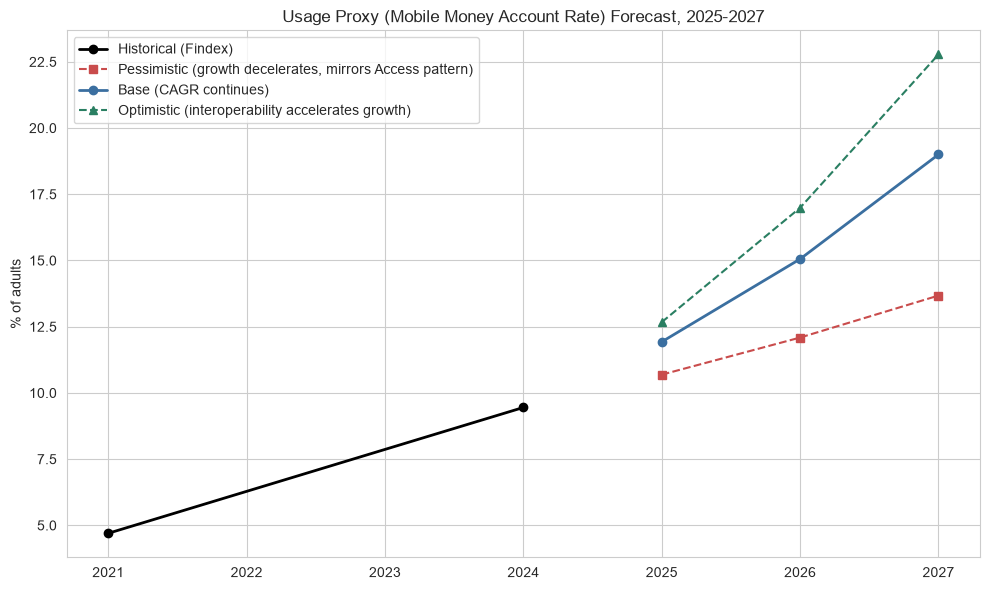

   year  pessimistic  base  optimistic
0  2025         10.7  11.9        12.7
1  2026         12.1  15.1        17.0
2  2027         13.7  19.0        22.8


In [7]:
mm_base_forecast = [mm_2024 * (1 + cagr) ** (y - 2024) for y in forecast_years]
mm_decelerating = [mm_2024 * (1 + cagr * 0.5) ** (y - 2024) for y in forecast_years]
mm_accelerating = [mm_2024 * (1 + cagr * 1.3) ** (y - 2024) for y in forecast_years]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mm["observation_date"].dt.year, mm["value_numeric"], marker="o", color="black", linewidth=2, label="Historical (Findex)")
ax.plot(forecast_years, mm_decelerating, marker="s", linestyle="--", color="#c94c4c", label="Pessimistic (growth decelerates, mirrors Access pattern)")
ax.plot(forecast_years, mm_base_forecast, marker="o", linestyle="-", color="#3b6fa0", linewidth=2, label="Base (CAGR continues)")
ax.plot(forecast_years, mm_accelerating, marker="^", linestyle="--", color="#2a7f62", label="Optimistic (interoperability accelerates growth)")
ax.set_title("Usage Proxy (Mobile Money Account Rate) Forecast, 2025-2027")
ax.set_ylabel("% of adults")
ax.legend()
plt.tight_layout()
plt.show()

usage_scenarios = pd.DataFrame({"year": forecast_years, "pessimistic": mm_decelerating,
                                 "base": mm_base_forecast, "optimistic": mm_accelerating})
print(usage_scenarios.round(1))

Combined forecast table

In [8]:
final_table = pd.DataFrame({
    "year": forecast_years,
    "access_pessimistic_%": scenarios["pessimistic"].round(1),
    "access_base_%": scenarios["base"].round(1),
    "access_optimistic_%": scenarios["optimistic"].round(1),
    "usage_proxy_pessimistic_%": usage_scenarios["pessimistic"].round(1),
    "usage_proxy_base_%": usage_scenarios["base"].round(1),
    "usage_proxy_optimistic_%": usage_scenarios["optimistic"].round(1),
})
final_table

,year,access_pessimistic_%,access_base_%,access_optimistic_%,usage_proxy_pessimistic_%,usage_proxy_base_%,usage_proxy_optimistic_%
0,2025,50.0,55.3,57.7,10.7,11.9,12.7
1,2026,51.0,58.3,61.4,12.1,15.1,17.0
2,2027,52.0,61.0,64.1,13.7,19.0,22.8


## Interpretation

**Access will very likely miss the 70% target.** All three scenarios put 2025
Access at 50-58% \u2014 12-20pp below the dataset's own REC_0031 target of 70% by
2025. Even the optimistic scenario only reaches 64% by 2027. This is the
single most consortium-relevant finding: current policy and product momentum
is insufficient to hit stated national targets, and closing the gap would
require either much stronger interventions or a longer timeline.

**Usage (proxy) grows faster in relative terms but from a tiny base.** Mobile
money account penetration is forecast to roughly double again by 2027 in the
base case (9.45% \u2192 19%), consistent with the accelerating Usage-vs-Access
divergence documented in Task 2.

## Key remaining uncertainties

- **Scope gap:** the brief's exact Usage indicator (Digital Payment Adoption
  Rate) has zero baseline observations in the dataset. ACC_MM_ACCOUNT is used
  as the best available proxy, but a true digital-payment-adoption forecast
  is not currently possible with the given data \u2014 flagged for future data
  collection.
- **n=4 for Access, n=2 for the Usage proxy.** Both are far below what
  standard forecasting practice would consider reliable; confidence intervals
  on the Access baseline are consequently wide (\u00b114-16pp by 2027), and the
  Usage proxy has no statistically valid interval at all.
- **The 0.153x calibration factor (Task 3) is a single global correction**,
  not a per-event validated parameter \u2014 it corrects the *aggregate*
  over-prediction but doesn't guarantee any individual event's estimate is
  accurate in isolation.
- **No new/future events are assumed** beyond the 11 already cataloged \u2014
  any additional policy action, product launch, or shock between now and
  2027 is not reflected in any scenario.